# I. Data preparation

Loading data from source

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib
import tensorflow.keras.layers as tfl
import os
import pickle
import keras_tuner as kt

In [2]:
from zipfile import ZipFile

# uncomment to load data
# zip_dir = 'data/emotion_data.zip'
# extraction_dir = ""

# with ZipFile(zip_dir, 'r') as zip_object:
#     zip_object.extractall(path=extraction_dir)

# print(f"All files extracted from '{zip_dir}' to '{extraction_dir}'.")

data_dir = pathlib.Path("emotion_data/")

Viewing training data

In [3]:
num_train_images = len(list(data_dir.glob("train/*/*")))
print("Images:", num_train_images)
print("Classes:", list(data_dir.glob("train/*")))

Images: 28709
Classes: [WindowsPath('emotion_data/train/angry'), WindowsPath('emotion_data/train/disgust'), WindowsPath('emotion_data/train/fear'), WindowsPath('emotion_data/train/happy'), WindowsPath('emotion_data/train/neutral'), WindowsPath('emotion_data/train/sad'), WindowsPath('emotion_data/train/surprise')]


In [4]:
train_dir = pathlib.Path("emotion_data/train")

batch_size = 64
# img_height = 180
# img_width = 180
val_split = 0.2

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split,
    subset="both",
    seed=91,
    image_size=(48,48),
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True,
    label_mode='categorical'
)
# train_ds = train_ds.shuffle(buffer_size=len(list(train_ds.as_numpy_iterator())))
# val_ds = val_ds.shuffle(buffer_size=len(list(val_ds.as_numpy_iterator())))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.


## Training preparation

In [5]:
class_names = train_ds.class_names
image_shape = None
labels_shape = None
num_classes = len(class_names)

for image_batch, labels_batch in train_ds:
    image_shape = image_batch.shape[1:]
    labels_shape = labels_batch.numpy().shape[1:]
    print(image_batch.shape, labels_batch.shape)
    break

print(class_names, image_shape, labels_shape)

(64, 48, 48, 3) (64, 7)
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] (48, 48, 3) (7,)


Dataset configuration

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

subset_reduction_factor_train = 0.2
subset_reduction_factor_val = 0.2
num_batches = num_train_images//batch_size

train_subset_size = int(num_batches*(1-val_split)*subset_reduction_factor_train)
val_subset_size = int(num_batches*val_split*subset_reduction_factor_val)

used_train_ds = train_ds.cache().take(train_subset_size).prefetch(buffer_size=AUTOTUNE)
used_val_ds = val_ds.cache().take(val_subset_size).prefetch(buffer_size=AUTOTUNE)

train_subset_size, val_subset_size

(71, 17)

Viewing training and validation data to ensure similar representations

# 2. Training

## Utilities

### Save/load utilities

Every time a distinct model is trained and/or used for observations, call `set_save_paths(model_name: str)`. Use the paths `checkpoint_path` and `base_path`, as well as the subroutines below, accordingly.

Information that can be saved and loaded are the training history and the parameters of a model.

By default, models load pretrained weights. Cells containing `model.fit()` can be optionally run once or multiple times by changing the cell format from raw to Python.

To train a fresh model, delete/rename the `training` folder (or its specific subfolders)

In [7]:
base_path:str = None
checkpoint_path:str = None
current_model_name:str = None

In [8]:
def create_path(filepath, isfile=True):
    path = pathlib.Path(filepath)
    if isfile:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.touch(exist_ok=True)
    else:
        path.mkdir(parents=True, exist_ok=True)

def set_save_paths(model_name:tf.keras.Model):
    global checkpoint_path
    global base_path
    global current_model_name
    current_model_name = model_name
    base_path = f"training/{model_name}"
    checkpoint_path = f"{base_path}/parameters.weights.h5"
    print("Save path now belongs to", current_model_name)

def load_parameters(model, custom_model_name=None):
    global checkpoint_path
    global base_path
    global current_model_name

    used_model_name = custom_model_name if custom_model_name != None else current_model_name
    used_checkpoint_path = f"training/{used_model_name}/parameters.weights.h5"

    if not os.path.isfile(used_checkpoint_path):
        print("No parameters found, no parameters loaded from", used_model_name)
        return

    print("Loading parameters of", used_model_name, f"({'Custom' if custom_model_name != None else 'Default'})")

    model.load_weights(used_checkpoint_path, skip_mismatch=True)

def save_object(object, name="history"):
    global checkpoint_path
    global base_path
    global current_model_name

    path = f"{base_path}/{name}"

    create_path(path, isfile=False)

    all_items = os.listdir(path)
    files_only = [os.path.join(path, item) for item in all_items]
    files_only = [item for item in files_only if os.path.isfile(item)]
    
    filepath = f"{path}/{len(files_only)}.pickle"
    create_path(filepath)
    
    print(f"Saving {name} of", current_model_name)
    with open(filepath, 'wb') as f:
        pickle.dump(object.history if name=="history" else object, f)

def load_object(name="history"):
    global checkpoint_path
    global base_path
    global current_model_name
    
    path = f"{base_path}/{name}"

    print(f"Loading {name} of", current_model_name)
    histories = []
    for i in os.listdir(path):
        curpath = os.path.join(path, i)
        if not os.path.isfile(curpath):
            continue
        with open(curpath, 'rb') as f:
            histories.append(pickle.load(f))
    return histories

def plot_object(chosen_attributes, ylim1=0, ylim2=1, name="history"):
    objects = load_object(name)
    for i in chosen_attributes:
        attribute_list = [item for cur_object in objects for item in cur_object[i]]
        plt.plot(np.arange(len(attribute_list)), attribute_list, label=i)
    plt.legend()
    plt.ylim(ylim1, ylim2)
    plt.title(f"{name} of {current_model_name}")
    plt.show()

### Evaluation utilities

In [9]:
def full_evaluation(model, history=None):
    if history is not None:
        save_object(history)
    plot_object(["val_accuracy", "accuracy"])
    plot_object(["val_loss", "loss"], None, None)
    print("Train:", model.evaluate(used_train_ds, return_dict=True))
    print("Validation:", model.evaluate(used_val_ds, return_dict=True))

## Loading model

Save path now belongs to finalized_MobileNetV2


C:\Users\User\AppData\Local\Temp\ipykernel_22332\3506833760.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Loading parameters of finalized_MobileNetV2 (Custom)
Loading history of finalized_MobileNetV2


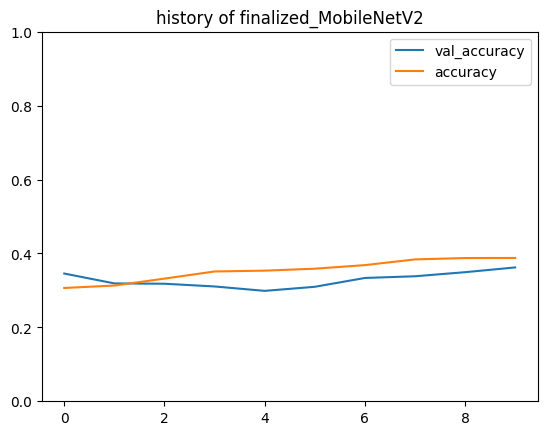

Loading history of finalized_MobileNetV2


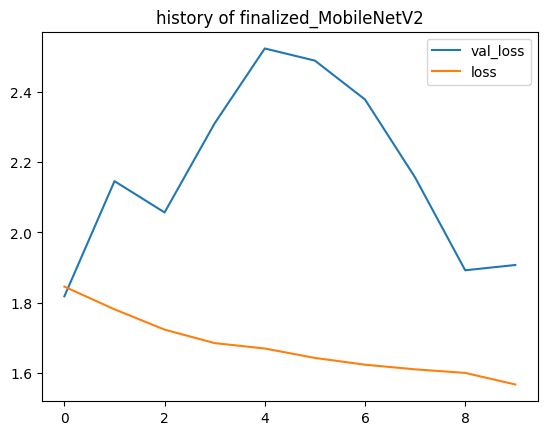

71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.4538 - loss: 1.5080
Train: {'accuracy': 0.4537852108478546, 'loss': 1.508013129234314}
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.3621 - loss: 1.9071
Validation: {'accuracy': 0.36213234066963196, 'loss': 1.9070782661437988}


In [14]:
set_save_paths(f"finalized_MobileNetV2")
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

INPUTS = tf.keras.Input(shape=image_shape)

L = tfl.Rescaling(1./255)(INPUTS)

# augmentation
L = tfl.RandomFlip("horizontal", input_shape=image_shape)(L)
L = tfl.RandomRotation(0.05)(L)
L = tfl.RandomZoom(height_factor=(-0.1, 0))(L)

L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dense(64, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

load_parameters(model, custom_model_name="finalized_MobileNetV2")

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

base_model.trainable = True
fine_tune_at = 140  # unfreeze from this layer onwards
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# lower lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# history = model.fit(
#     used_train_ds,
#     validation_data=used_val_ds,
#     epochs=10,
#     callbacks=[cp_callback, es_callback],
#     verbose=1
# )

full_evaluation(model)

## Hyperband near-head tuning

In [ ]:
def builder(hp):
    # set_save_paths(f"finalized_MobileNetV2")
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        input_shape=image_shape,
        weights='imagenet'
    )

    INPUTS = tf.keras.Input(shape=image_shape)

    L = tfl.Rescaling(1./255)(INPUTS)

    # augmentation
    L = tfl.RandomFlip("horizontal", input_shape=image_shape)(L)
    L = tfl.RandomRotation(0.05)(L)
    L = tfl.RandomZoom(height_factor=(-0.1, 0))(L)

    L = base_model(L, training=False)
    L = tfl.GlobalAveragePooling2D()(L)
    L = tfl.Dense(128, activation='relu')(L)
    L = tfl.Dense(64, activation='relu')(L)
    L = tfl.Dropout(0.58)(L)
    OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

    model = tf.keras.Model(INPUTS, OUTPUTS)

    load_parameters(model, custom_model_name="finalized_MobileNetV2")

    base_model.trainable = True
    fine_tune_at = 140  # unfreeze from this layer onwards
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # lower lr
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    full_evaluation(model)

# cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',  # Metric to monitor (e.g., validation loss)
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restores model weights from the epoch with the best monitored value
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3
)

tuner = kt.Hyperband(builder,
                     objective='val_accuracy',
                     max_epochs=20,
                     factor=3,
                     directory="tuning",
                     project_name='hyperband_tuning')

tuner.search(
    used_train_ds,
    validation_data=used_val_ds, 
    epochs=50, 
    callbacks=[es_callback, lr_callback]
)


Reloading Tuner from tuning\hyperband_tuning\tuner0.json


# 3. Testing and evaluation

## On test data

In [12]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    pathlib.Path("emotion_data/test"),
    seed=91,
    image_size=(48,48),
    batch_size=10000,
    color_mode='grayscale',
    shuffle=True,
    label_mode='categorical'
)

L = None
y = None

for x_batch, y_batch in test_ds:
    L = x_batch.numpy()
    y = y_batch.numpy()
    break

L.shape, y.shape

Found 7178 files belonging to 7 classes.


((7178, 48, 48, 1), (7178, 7))

In [13]:
model.evaluate(test_ds, return_dict=True)

InvalidArgumentError: Graph execution error:

Detected at node convolution defined at (most recent call last):
<stack traces unavailable>
Depth of input must be a multiple of depth of filter: 1 vs 3

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
File "c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
File "c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
File "c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\base_events.py", line 608, in run_forever
File

## Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


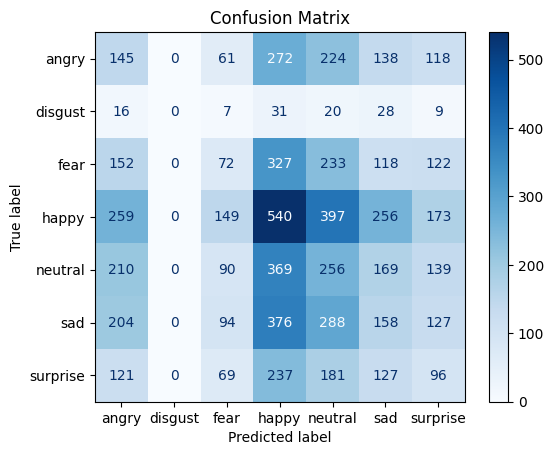

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(test_ds), axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Basically every other experiment on this dataset would tell you that `happy` is the most easily recognized and `disgust` is the least. This is true for this experiment as well.

## Testing own data
Image is of my friends

In [ ]:
model.evaluate(test_ds, return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5417 - loss: 1.6985


{'accuracy': 0.5416666865348816, 'loss': 1.6985472440719604}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


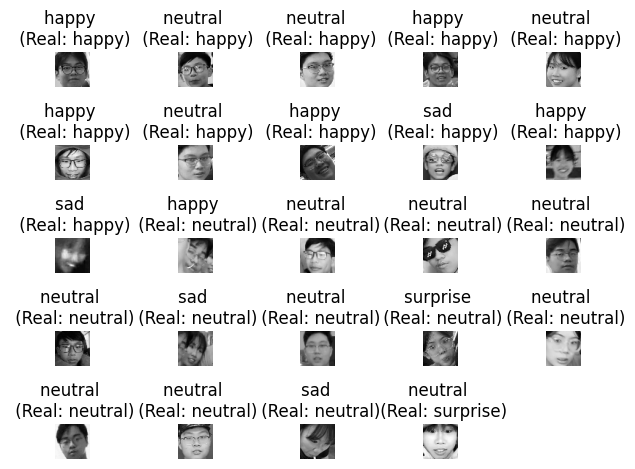

In [ ]:

y_pred = np.argmax(model.predict(test_ds), axis=1)
for image_batch, labels_batch in test_ds:
    for index, image in enumerate(image_batch):
        label = np.argmax(labels_batch[index].numpy())
        ax = plt.subplot(5, int(np.ceil(image_batch.shape[0]/5)), index+1)
        ax.imshow(image.numpy().astype("uint8"), cmap="gray")
        ax.axis("off")
        ax.set_title(f"{class_names[int(y_pred[index])]} \n (Real: {class_names[int(label)]})")
    break
plt.tight_layout()
plt.show()

# 4. Conclusion